<a href="https://colab.research.google.com/github/MelB18/EasyQuanten/blob/main/ErsteSchritte.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vorbereitung

Als Erstes müssen wir verschiedene Python Bibliotheken installieren und importieren.


In [2]:
# Install required packages.

%pip install --upgrade 'qiskit[visualization]>=2.5.0' qiskit-aer qiskit-ibm-runtime matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 99.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.8/120.8 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.

In [1]:
import os
import platform
import shutil
import subprocess
import sys

import qiskit

from qiskit.circuit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import SparsePauliOp, Statevector, Operator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import array_to_latex, plot_histogram, plot_state_qsphere, plot_bloch_multivector
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import Batch, QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

import matplotlib.pyplot as plt
import numpy as np

from numpy import sqrt

print(f"Qiskit version: {qiskit.__version__}")

Qiskit version: 2.5.2


# Basiswissen

In diesem Kapitel werden die wichtigsten Grundlagen erklärt.

## Bits versus Qubits

Bits können den Wert 0 oder 1 haben, ähnlich wie Münzen Kopf oder Zahl sein können.

Wenn Münzen flach auf dem Tisch liegen, ist die Wahrscheinlich für Kopf oder Zahl jeweils 100% oder 0%.

Wirft man die Münze in die Luft, ist die Wahrscheinlichkeit - solange sie in der Luft ist - irgendwas dazwischen.

Zum Beispiel: 30% Kopf und 70% Zahl

Ein entsprechender Wahrscheinlichkeitsvektor kann wie folgt definiert werden:

$$
\begin{pmatrix}
0.3
\\
0.7
\end{pmatrix}
$$

In [2]:
bitVec = np.array([[0.3],[0.7]])

print("Wahrscheinlichkeitsvektor (30% Kopf und 70% Zahl): ")
print(bitVec)
display(array_to_latex(bitVec))

Wahrscheinlichkeitsvektor (30% Kopf und 70% Zahl): 
[[0.3]
 [0.7]]


<IPython.core.display.Latex object>

Für einen Wahrscheinlichkeitsvektor muss festgelegt werden, welcher Wert oben/als erstes und welcher Wert unten/als zweites steht.

In unserem Beispiel kommt zuerst die Wahrscheinlichkeit  für Kopf und danach die Wahrscheinlichkeit für Zahl.

Wichtig: Damit es ein gültiger Wahrscheinlichkeitsvektor ist, muss der Vektor aus reelen Zahlen zwischen 0 und 1 bestehen, die in Summe 1 ergeben.

In [3]:
print("Wahrscheinlichkeit Kopf: ",bitVec[0])
print("Wahrscheinlichkeit Zahl: ",bitVec[1])
print("Summe: ",bitVec[0]+bitVec[1])


Wahrscheinlichkeit Kopf:  [0.3]
Wahrscheinlichkeit Zahl:  [0.7]
Summe:  [1.]


Für Wahrscheinlichkeitsvektoren von Bits ist die allgemeine Festlegung, dass oben die Wahrscheinlichkeit von 0 und unten die Wahrscheinlichkeit von 1 steht.

Der Wahrscheinlichkeitsvektor für 100% Wert 0 sieht wie folgt aus:

$$
\begin{pmatrix}
1
\\
0
\end{pmatrix}
$$


In [4]:
bitZero = np.array([[1],[0]])
bitOne = np.array([[0],[1]])

print("Wahrscheinlichkeitsvektor für 100% Wert 0 (und 0% Wert 1): ")
print(bitZero)
display(array_to_latex(bitZero))
print("\nWahrscheinlichkeitsvektor für 100% Wert 1 (und 0% Wert 0): ")
print(bitOne)
display(array_to_latex(bitOne))

Wahrscheinlichkeitsvektor für 100% Wert 0 (und 0% Wert 1): 
[[1]
 [0]]


<IPython.core.display.Latex object>


Wahrscheinlichkeitsvektor für 100% Wert 1 (und 0% Wert 0): 
[[0]
 [1]]


<IPython.core.display.Latex object>

## Zustandsvektoren von Qubits

Qubits lassen sich ähnlich wie Bits als Vektor mit zwei Zahlen schreiben.

Es gibt jedoch zwei Hauptunterschiede:


1.   Der Vektor kann imaginäre Zahlen enthalten und nicht nur reele Zahlen
2.   Um die Wahrscheinlichkeiten zu bestimmen, müssen die Zahlen quadriert werden.


Wie bei einem Wahrscheinlichkeitsvektor eines Bit, muss bei einen Qubit Zustandsvektor die Summe der beiden Wahrscheinlichkeiten 1 ergeben.


Vektor für 100% Zustand 0 (und 0% Wert 1):

$$
\begin{pmatrix}
1
\\
0
\end{pmatrix}
$$

In [12]:
zero = Statevector([1,0])

print("Andere Schreibweise für diesen Vektor: ")
#display(zero.draw("text"))
display(zero.draw("latex"))

Andere Schreibweise für diesen Vektor: 


<IPython.core.display.Latex object>

Vektor für 100% Zustand 1 (und 0% Wert 0):


$$
\begin{pmatrix}
0
\\
1
\end{pmatrix}
$$

In [13]:
one = Statevector([0,1])

print("Andere Schreibweise für diesen Vektor: ")
#display(one.draw("text"))
display(one.draw("latex"))


Andere Schreibweise für diesen Vektor: 


<IPython.core.display.Latex object>

Um zu prüfen, ob ein gültiger Qubit Zustandsvektor definiert wurde, müssen die zwei Zahlen quadriert und danach addiert werden. Das Ergebnis muss dann 1 ergeben.


Die Prüfung kann mit Hilfe der folgenden Funktion durchgeführt werden:

In [7]:
display(zero.is_valid())
display(one.is_valid())

True

True

Die Bedeutung der Qubit Zustandsvektoren kann man mit Hilfe der Bloch Kugel visualisieren:

* 100% Zustand 0: Nordpol
* 100% Zustand 1: Südpol

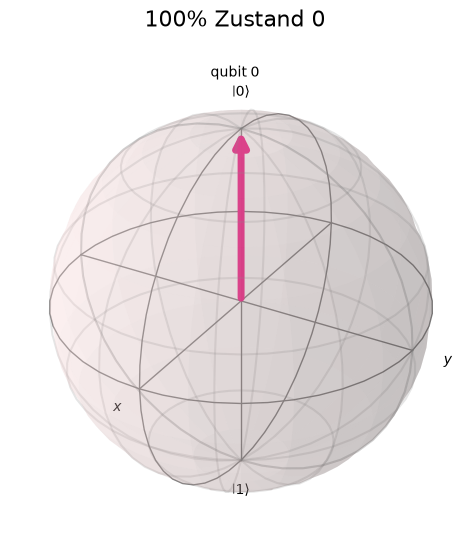

In [ ]:
plot_bloch_multivector(zero, "100% Zustand 0")

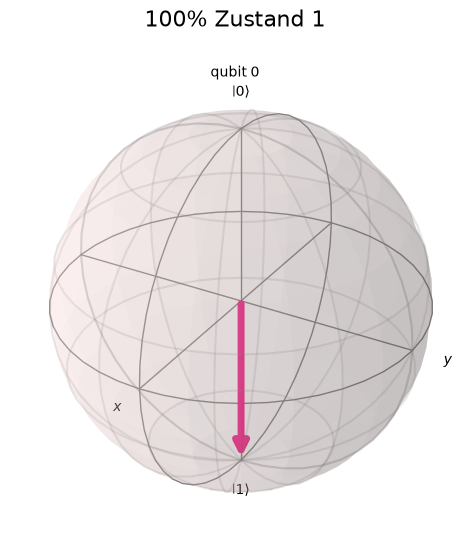

In [ ]:
plot_bloch_multivector(one, "100% Zustand 1")

## Berechnung des Bloch Vektors

## Beispiele

Weitere Beispiele für gültige Qubit Zustandsvektoren sind die folgenden Vektoren:

In [8]:

u = Statevector([sqrt(2)/2, sqrt(2)/2])
v = Statevector([(1/3 + 2/3j), -2 / 3])
w = Statevector([(-3/5), (4/5)])

print("Qubit_u =")
display(u.draw("text"))
display(u.draw("latex"))
print("\nQubit_v =")
display(v.draw("text"))
display(v.draw("latex"))
print("\nQubit_w =")
display(w.draw("text"))
display(w.draw("latex"))


Qubit_u =


[0.70710678+0.j,0.70710678+0.j]

<IPython.core.display.Latex object>


Qubit_v =


[ 0.33333333-0.66666667j,-0.66666667+0.j        ]

<IPython.core.display.Latex object>


Qubit_w =


[-0.6+0.j, 0.8+0.j]

<IPython.core.display.Latex object>

In [ ]:

print("Qubit_u gültig: ")
display(w.is_valid())
print("\nQubit_v gültig: ")
display(v.is_valid())
print("\nQubit_w gültig: ")
display(w.is_valid())

Qubit_u gültig: 


True


Qubit_v gültig: 


True


Qubit_w gültig: 


True

 Wenn das Qubit_u gemessen wird, ist das Ergebnis mit gleicher Wahrscheinlichkeit 0 und 1.

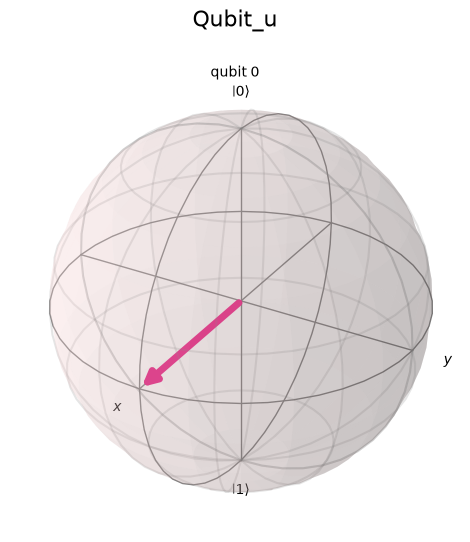

In [ ]:
plot_bloch_multivector(u,"Qubit_u")

In [ ]:
outcome, state = u.measure()
print(f"Gemessener Wert: {outcome}")


Gemessener Wert: 1


Ergebnis von 1000 Messungen:

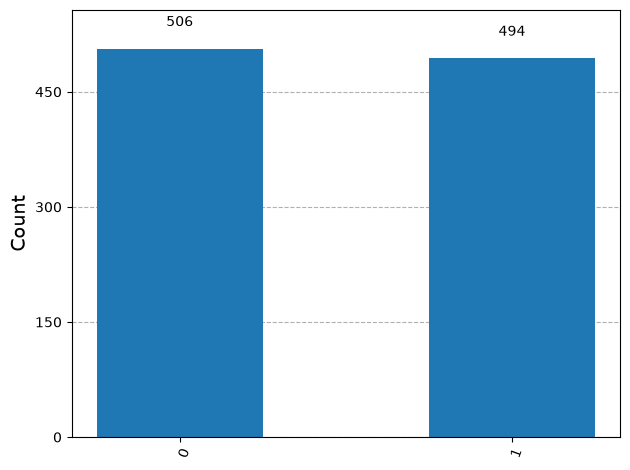

In [ ]:

statistics = u.sample_counts(1000)
plot_histogram(statistics)

Qubit_v enthält einen imaginären Anteil. Dadurch liegt der Pfeil nicht mehr in der x-z-Ebene. Er hat zusätzlich einen y Anteil.

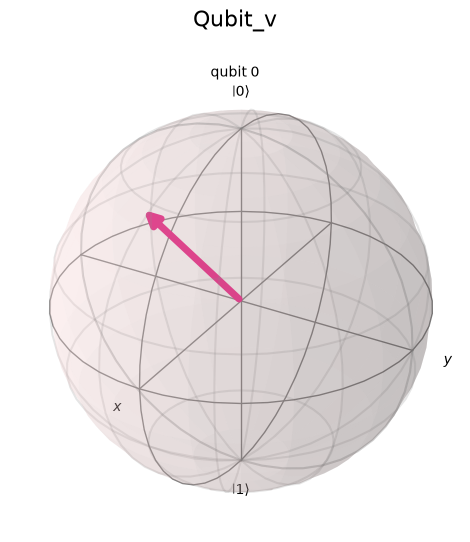

In [ ]:
plot_bloch_multivector(v, "Qubit_v")

Man sieht, dass der Pfeil nach oben zeigt - d.h. der Wert 0 ist wahrscheinlicher. Dies wird durch die wiederholte Messung bestätigt.

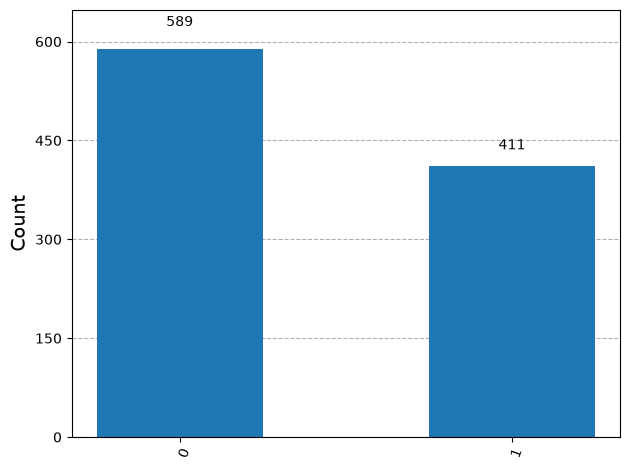

In [ ]:
statistics = v.sample_counts(1000)
plot_histogram(statistics)

Das Qubit_w liegt wieder in der x-z-Ebene. Bei diesem Qubit ist die Wahrscheinlichkeit von 1 größer als die Wahrscheinlichkeit für 0.

* Wahrscheinlichkeit 0: 9/25 = (-3/5) * (-3/5)
* Wahrscheinlichkeit 1: 16/25 = (4/5) * (4/5)

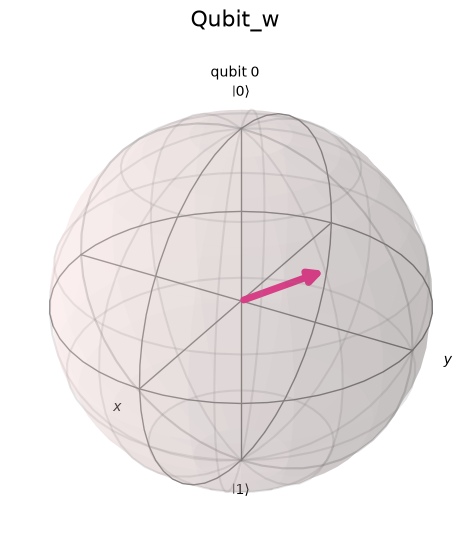

In [ ]:
plot_bloch_multivector(w, "Qubit_w")

Ergebnis von 2500 Messungen:

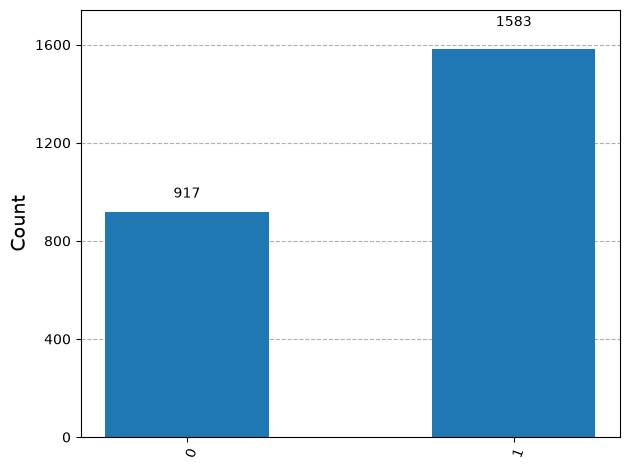

In [ ]:

statistics = w.sample_counts(2500)
plot_histogram(statistics)